### Overview
-> Obtain the wind data from Maspolomas 
-> Clean this data, find any anomalies -> document said anomalies 
-> Plot the graphs


In [1]:
# Modules
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ee
import pygame as pg
from scipy.stats import circmean, circstd
from statsmodels.tsa.seasonal import seasonal_decompose

pygame 2.6.1 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html



## Overview 
This notebook uses several modules which aims to demonstrate sand dune loss in Maspolomas, Gran Canaria from 2020 - 2021. The steps involved include obtaining weather data, satellite imagery and the visualisation of underlying seasonal statistics, such as wind speed, wind direction and NDVI (Normalized difference vegetation) to illustrate sand migration. In addition to this: a simulation using Brad Werner's sand dune simulation 

### Data
The first module used is the requests module which handles HTTP requests (GET,POST, etc) to web APIs. In this instance, the ``GET method``` is used to structure a query to obtain a response from [open mateo](open-meteo.com): the response will contain information on wind speed, wind gust and wind direction.

The second module used is pandas - the module reads, writes and provides methods to describe the data. For example, it reads file utils.json documenting the latitude, longitude, start and end date used for the project and saves the JSON response from the website into a CSV format.

The visualisations modules used are Matplotlib and Seaborn. Seaborn is used for out of the box attrative visualisations while Matplotlib is used for plots not covered by seaborn, e.g. wind rose plots. 

In [2]:
# Load coordinates, start and end dates from utils.json using pandas
# typ='series' allows us to access the data as key-value pairs
utils = pd.read_json('utils.json', typ='series')

# Define CSV filename where the wind data will be saved
csv_filename = 'wind_data_2020_2021.csv'

# Creates a request to Open-Meteo Historical Weather API
url = "https://archive-api.open-meteo.com/v1/archive"

# Prepare parameters for the API request
# All parameters are taken from the utils.json file
params = {
    "latitude": utils["lat"],
    "longitude": utils["lon"],
    "start_date": utils["start_date"],
    "end_date": utils["end_date"],
    "hourly": "wind_speed_10m,wind_direction_10m,wind_gusts_10m",
    "timezone": "auto"
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
    
    # Create DataFrame directly from the API response
    df = pd.DataFrame({
        'datetime': data['hourly']['time'],
        'wind_speed': data['hourly']['wind_speed_10m'],
        'wind_direction': data['hourly']['wind_direction_10m'],
        'wind_gusts': data['hourly']['wind_gusts_10m']
    })
    
    # Write to CSV using pandas
    df.to_csv(csv_filename, index=False)
    
    print(f"Successfully saved {len(df)} hours of wind data to {csv_filename}")
    print(f"Data includes: wind speed, direction, and gusts (all at 10m height)")
    
else:
    print(f"Error: {response.status_code}")
    print(response.text)

Successfully saved 17544 hours of wind data to wind_data_2020_2021.csv
Data includes: wind speed, direction, and gusts (all at 10m height)


In [3]:
df = pd.read_csv('wind_data_2020_2021.csv')
df.describe()

,wind_speed,wind_direction,wind_gusts
count,17544.000000,17544.000000,17544.000000
mean,16.374612,122.837494,26.458881
std,7.090365,92.363454,10.467982
min,0.000000,1.000000,1.100000
25%,11.500000,53.000000,19.100000
50%,16.100000,90.000000,25.900000
75%,20.900000,171.000000,33.100000
max,49.800000,360.000000,76.300000


In [4]:
df.shape

(17544, 4)

Wind data needs to converted into degrees as scipy functions require radians. Additionally, averaging fails with circular data, e.g. 10, 20 and 340 gives 127 - not 357 the correct northerly direction.

In [5]:
# Convert to radians for scipy
wind_dir_rad = np.radians(df['wind_direction'])

# Proper circular statistics
circular_mean = np.degrees(circmean(wind_dir_rad))
circular_std = np.degrees(circstd(wind_dir_rad))

print(f"Circular mean: {circular_mean:.2f}°")
print(f"Circular std: {circular_std:.2f}°")

Circular mean: 75.98°
Circular std: 73.79°


In [6]:
# Counts the number of zero wind entries
zero_count = (df['wind_speed'] == 0).sum()
# Returns any zero wind speed observations then the corresponding datetime, wind speed, direction, and gusts
zero_wind_data = df[df['wind_speed'] == 0]

print(f"Number of zero wind speed entries: {zero_count}")
print("\nZero wind speed observations:")
print(zero_wind_data[['datetime', 'wind_speed', 'wind_direction', 'wind_gusts']])

Number of zero wind speed entries: 2

Zero wind speed observations:
              datetime  wind_speed  wind_direction  wind_gusts
1026  2020-02-12T18:00         0.0             270        10.1
4332  2020-06-29T12:00         0.0             270        14.8


Entries with ``0`` suggest that wind was present but below the sensor's minimum threshold. [Open-Meteo](https://open-meteo.com/en/about) does not provide information on the types of sensors used to obtain metrological data. Given this issue - and it's occurance < 1.39 % a proxy value of 0.1 is used. 

In [7]:
df['wind_speed'] = df['wind_speed'].replace(0, 0.1)
print(f'Check if zero wind speed entries are replaced with 0.1: {(df["wind_speed"] == 0.1).sum()}')

Check if zero wind speed entries are replaced with 0.1: 2


Wind gusts must also be checked against wind speed as wind gusts by definition are typically higher or equal to the sustained wind speed [Met Office](https://weather.metoffice.gov.uk/guides/observations/how-we-measure-wind).

In [8]:
# Check for impossible physics: gusts < sustained wind
impossible = df[df['wind_gusts'] < df['wind_speed']]
print(f"Impossible observations (gusts < wind speed): {len(impossible)}")

Impossible observations (gusts < wind speed): 35


In [9]:
# Look at the problematic data
print("Impossible observations:")
print(impossible[['datetime', 'wind_speed', 'wind_direction', 'wind_gusts']])

# This checks the severity of the problem
print(f"\nDifference analysis:")
print(f"Average wind speed in impossible cases: {impossible['wind_speed'].mean():.2f}")
print(f"Average gusts in impossible cases: {impossible['wind_gusts'].mean():.2f}")
print(f"Average difference (wind - gusts): {(impossible['wind_speed'] - impossible['wind_gusts']).mean():.2f}")

Impossible observations:
               datetime  wind_speed  wind_direction  wind_gusts
105    2020-01-05T09:00         1.5             135         1.4
1341   2020-02-25T21:00         3.3             221         3.2
1898   2020-03-20T02:00        13.6              50        11.9
2258   2020-04-04T02:00        21.6             298        15.8
2445   2020-04-11T21:00         8.9              47         7.6
3118   2020-05-09T22:00         7.4              47         6.8
4130   2020-06-21T02:00         6.5             161         6.1
5282   2020-08-08T02:00        24.5              87        19.4
5666   2020-08-24T02:00        13.5              42        12.6
7874   2020-11-24T02:00        12.4             330        11.9
8210   2020-12-08T02:00         9.4              18         9.0
8517   2020-12-20T21:00         5.0              60         4.7
8858   2021-01-04T02:00         8.0             333         5.4
8978   2021-01-09T02:00         5.6             105         4.0
9120   2021-01-

In [10]:
# Fix by setting gusts equal to wind speed for these cases
# This is the most conservative approach that maintains data integrity
df.loc[impossible.index, 'wind_gusts'] = df.loc[impossible.index, 'wind_speed']

print(f"Fixed {len(impossible)} impossible observations by setting gusts = wind speed")

# Verify the fix
check = df[df['wind_gusts'] < df['wind_speed']]
print(f"Remaining impossible observations: {len(check)}")

Fixed 35 impossible observations by setting gusts = wind speed
Remaining impossible observations: 0


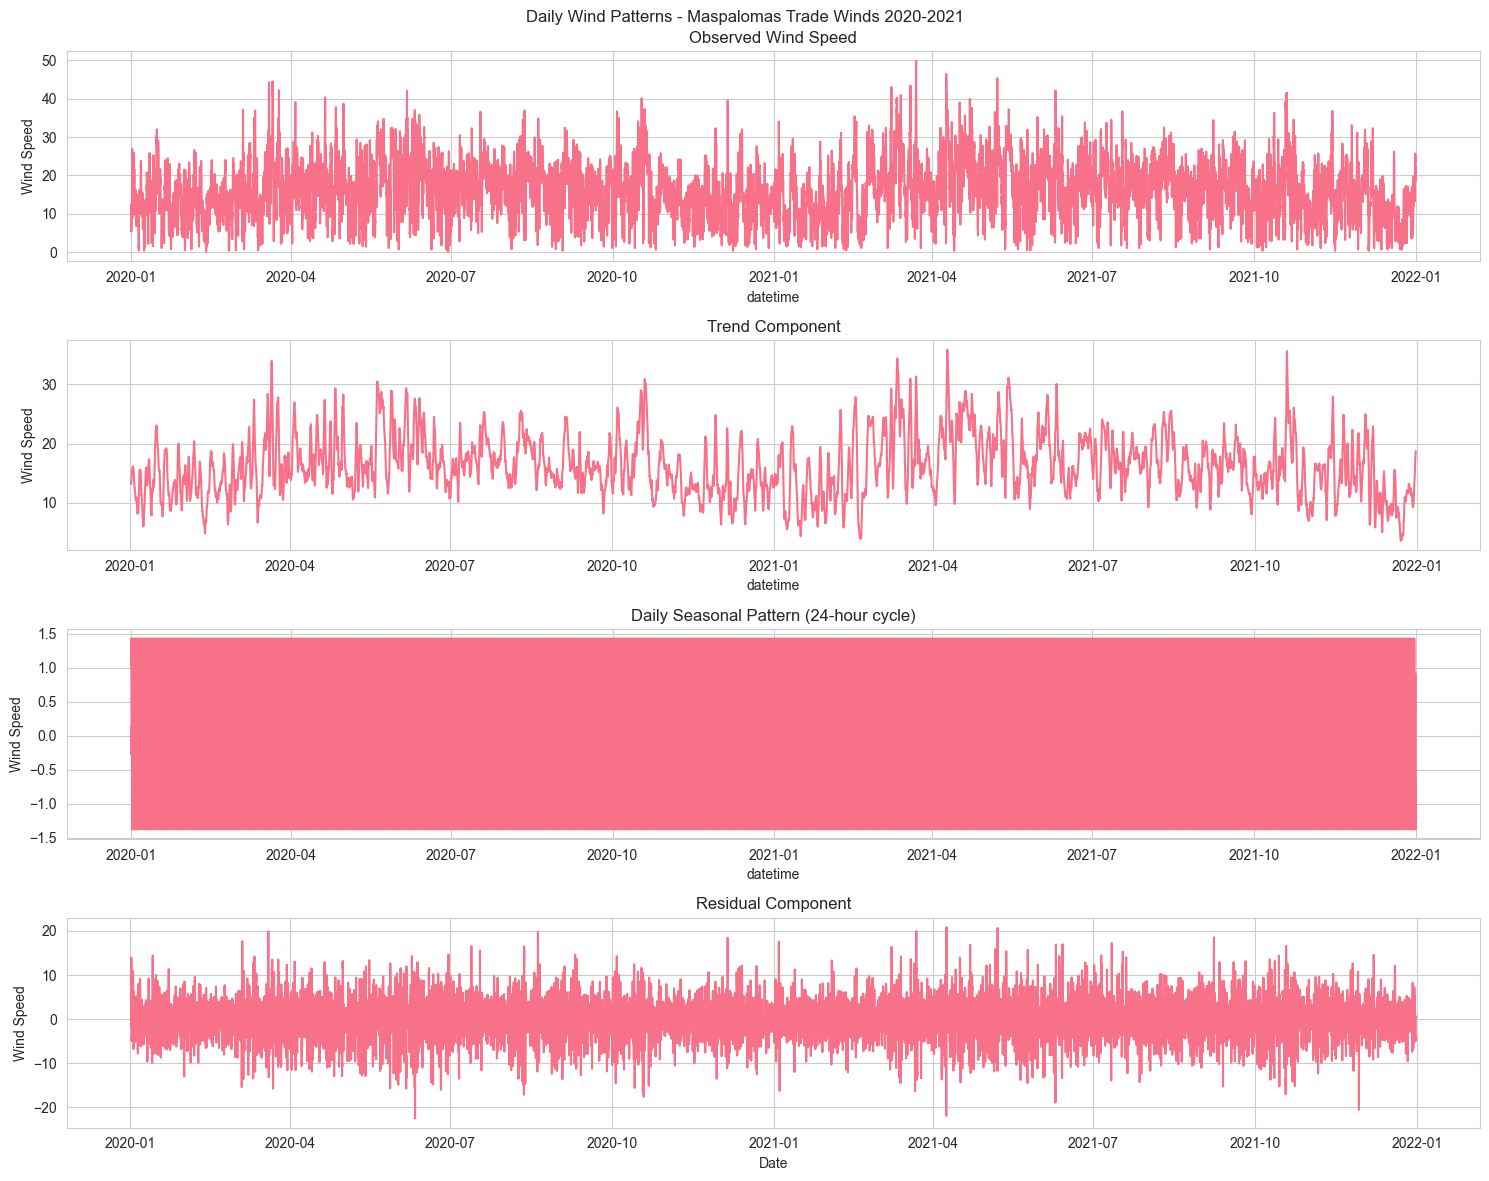

In [11]:
sns.set_style("whitegrid")
sns.set_palette("husl")

df['datetime'] = pd.to_datetime(df['datetime'])
df_ts = df.set_index('datetime')

daily_decomp = seasonal_decompose(df_ts['wind_speed'], 
                                model='additive',
                                period=24)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

sns.lineplot(x=daily_decomp.observed.index, y=daily_decomp.observed.values, ax=axes[0])
axes[0].set_title('Observed Wind Speed')
axes[0].set_ylabel('Wind Speed')

sns.lineplot(x=daily_decomp.trend.index, y=daily_decomp.trend.values, ax=axes[1])
axes[1].set_title('Trend Component')
axes[1].set_ylabel('Wind Speed')

sns.lineplot(x=daily_decomp.seasonal.index, y=daily_decomp.seasonal.values, ax=axes[2])
axes[2].set_title('Daily Seasonal Pattern (24-hour cycle)')
axes[2].set_ylabel('Wind Speed')

sns.lineplot(x=daily_decomp.resid.index, y=daily_decomp.resid.values, ax=axes[3])
axes[3].set_title('Residual Component')
axes[3].set_ylabel('Wind Speed')
axes[3].set_xlabel('Date')

plt.suptitle('Daily Wind Patterns - Maspalomas Trade Winds 2020-2021')
plt.tight_layout()
plt.show()


Seasonal decomposition is used as wind speed is a key parameter controlling aeolion transport. The decomposition separates wind variability into three components(trend, seasonal, daily cycles) verses random fluctuations. 

C:\Users\Stephen McGuinness\AppData\Local\Temp\ipykernel_17932\1489170113.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_rose_data = df.groupby('dir_binned')['wind_speed'].agg(['mean', 'count']).reset_index()


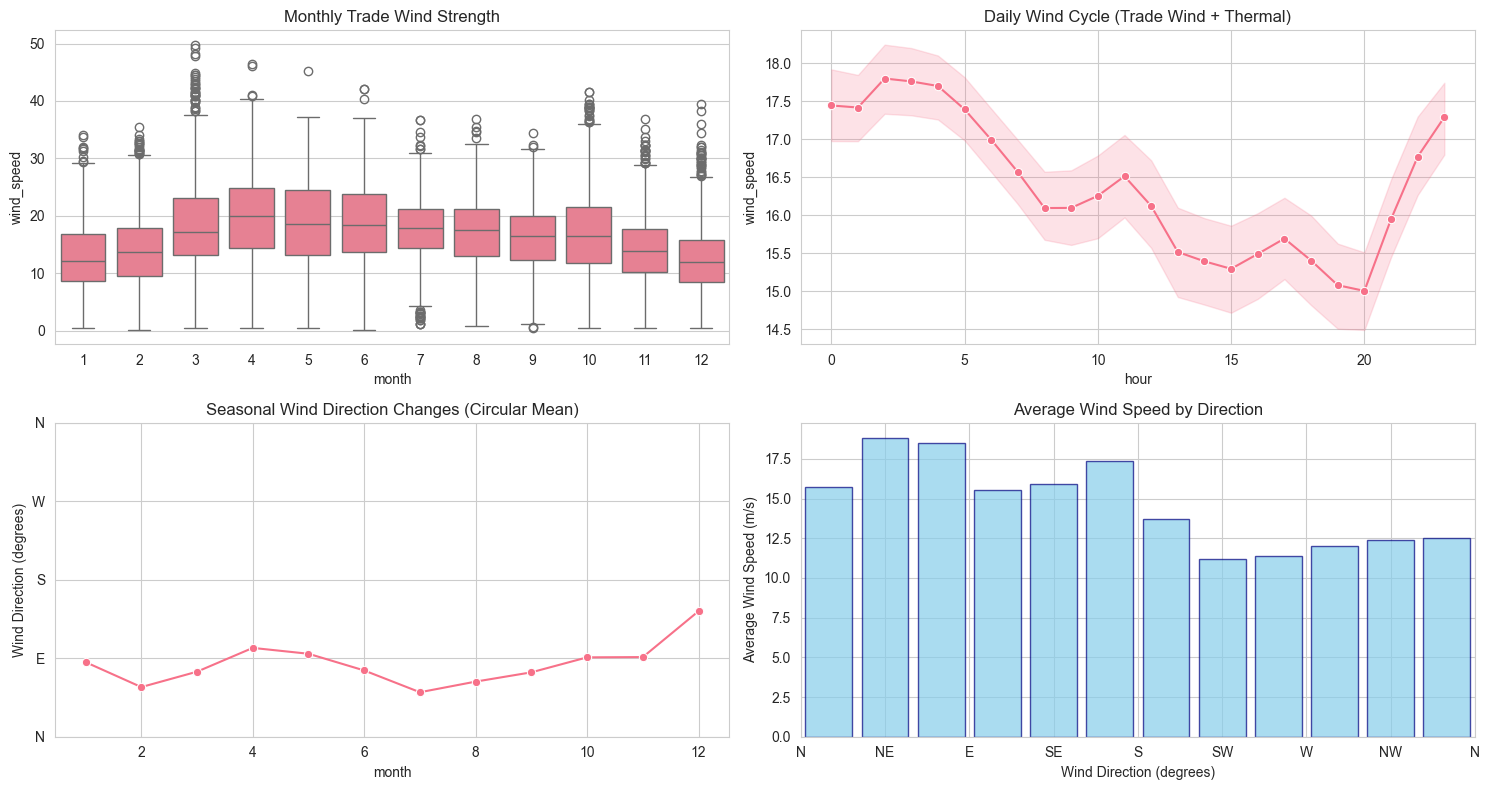

In [12]:
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

sns.boxplot(data=df, x='month', y='wind_speed', ax=axes[0,0])
axes[0,0].set_title('Monthly Trade Wind Strength')

sns.lineplot(data=df, x='hour', y='wind_speed', ax=axes[0,1], marker='o')
axes[0,1].set_title('Daily Wind Cycle (Trade Wind + Thermal)')

# FIXED: Proper circular handling for wind direction boxplot
# Convert wind direction to circular statistics for each month
monthly_circular_stats = []
for month in sorted(df['month'].unique()):
    month_data = df[df['month'] == month]['wind_direction']
    # Convert to radians
    wind_dir_rad = np.radians(month_data)
    # Calculate circular mean and convert back to degrees
    circular_mean = np.degrees(circmean(wind_dir_rad))
    # Ensure mean is between 0-360
    if circular_mean < 0:
        circular_mean += 360
    monthly_circular_stats.append({'month': month, 'circular_mean': circular_mean})

circular_df = pd.DataFrame(monthly_circular_stats)

# Plot as line plot instead of boxplot for circular data
sns.lineplot(data=circular_df, x='month', y='circular_mean', ax=axes[1,0], marker='o')
axes[1,0].set_title('Seasonal Wind Direction Changes (Circular Mean)')
axes[1,0].set_ylabel('Wind Direction (degrees)')
axes[1,0].set_ylim(0, 360)
axes[1,0].set_yticks([0, 90, 180, 270, 360])
axes[1,0].set_yticklabels(['N', 'E', 'S', 'W', 'N'])

# FIXED: Wind rose instead of scatter plot
# Create direction bins for wind rose
direction_bins = np.arange(0, 361, 30)  # 30-degree bins
direction_centers = direction_bins[:-1] + 15

# Bin the directions and calculate mean wind speed for each bin
df['dir_binned'] = pd.cut(df['wind_direction'], bins=direction_bins, labels=direction_centers, include_lowest=True)
wind_rose_data = df.groupby('dir_binned')['wind_speed'].agg(['mean', 'count']).reset_index()

# Convert the regular subplot to show binned data
wind_rose_data['dir_binned'] = wind_rose_data['dir_binned'].astype(float)
bars = axes[1,1].bar(wind_rose_data['dir_binned'], wind_rose_data['mean'], 
                     width=25, alpha=0.7, color='skyblue', edgecolor='navy')

axes[1,1].set_xlabel('Wind Direction (degrees)')
axes[1,1].set_ylabel('Average Wind Speed (m/s)')
axes[1,1].set_title('Average Wind Speed by Direction')
axes[1,1].set_xlim(0, 360)
axes[1,1].set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360])
axes[1,1].set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])

plt.tight_layout()
plt.show()

Monthly boxplots is used to illustrate when wins are strongest/weakest by month. 

C:\Users\Stephen McGuinness\AppData\Local\Temp\ipykernel_17932\1361501202.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_rose_fine = df.groupby('dir_binned_fine')['wind_speed'].agg(['mean', 'count']).reset_index()


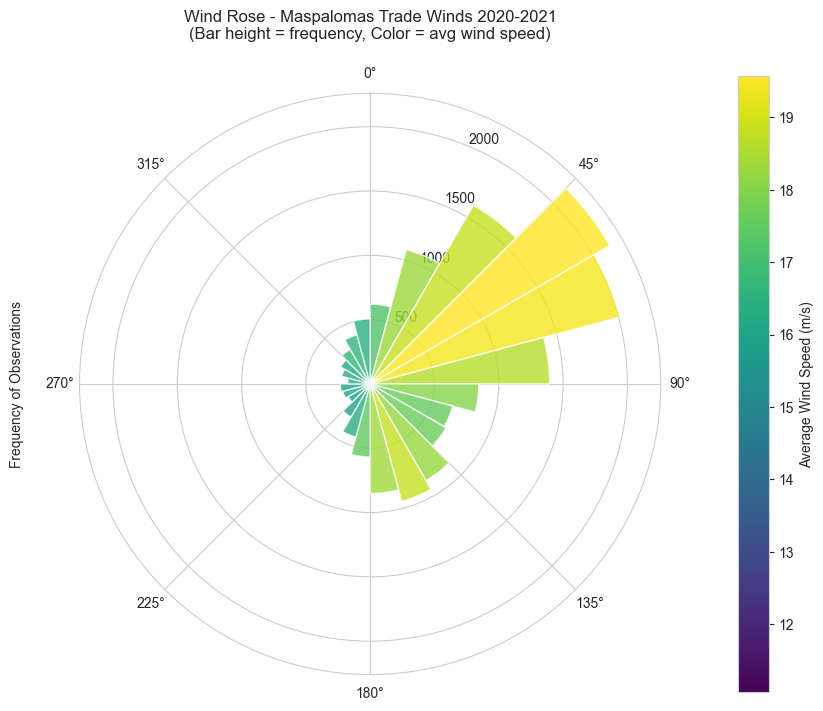

In [13]:
# BONUS: Create a proper wind rose plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Use finer bins for the wind rose
direction_bins_fine = np.arange(0, 361, 15)  # 15-degree bins
direction_centers_fine = direction_bins_fine[:-1] + 7.5

df['dir_binned_fine'] = pd.cut(df['wind_direction'], bins=direction_bins_fine, 
                               labels=direction_centers_fine, include_lowest=True)

wind_rose_fine = df.groupby('dir_binned_fine')['wind_speed'].agg(['mean', 'count']).reset_index()

# Convert to radians for polar plot
theta = np.radians(wind_rose_fine['dir_binned_fine'].astype(float))

# Create the wind rose with frequency (count) as bar height, colored by wind speed
bars = ax.bar(theta, wind_rose_fine['count'], 
              width=np.radians(15), 
              bottom=0,
              alpha=0.8)

# Color bars by average wind speed
colors = plt.cm.viridis(wind_rose_fine['mean']/wind_rose_fine['mean'].max())
for bar, color in zip(bars, colors):
    bar.set_facecolor(color)

# Set up the polar plot
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Wind Rose - Maspalomas Trade Winds 2020-2021\n(Bar height = frequency, Color = avg wind speed)', pad=20)
ax.set_ylabel('Frequency of Observations', labelpad=40)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, 
                          norm=plt.Normalize(vmin=wind_rose_fine['mean'].min(), 
                                           vmax=wind_rose_fine['mean'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.8)
cbar.set_label('Average Wind Speed (m/s)')

plt.show()

In [ ]:
import ee
import geemap

# Init & AOI
ee.Initialize(project='maps-451814')
aoi = ee.Geometry.Rectangle([-15.600, 27.730, -15.570, 27.750])

# Sentinel-2 image
img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
       .filterBounds(aoi)
       .filterDate('2023-06-01', '2024-12-31')
       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
       .sort('CLOUD_COVER')
       .first()
       .clip(aoi))

# --- White-roof building detection ---
def white_roof_buildings(img):
    # Bright & spectrally uniform in RGB
    rgb = img.select(['B2','B3','B4'])
    bright = rgb.reduce(ee.Reducer.mean()).gt(2550)
    cv = rgb.reduce(ee.Reducer.stdDev()).divide(rgb.reduce(ee.Reducer.mean()))
    uniform = cv.lt(0.15)

    # Not vegetation / not water
    ndvi = img.normalizedDifference(['B8','B4']).lt(0.2)
    ndwi = img.normalizedDifference(['B3','B8']).lt(0.0)

    # Built surface cues
    ndbi_ok = img.normalizedDifference(['B11','B8']).lt(0.1)
    nir_red_ratio_ok = img.select('B8').divide(img.select('B4')).lt(1.2)

    candidates = bright.And(uniform).And(ndvi).And(ndwi).And(ndbi_ok).And(nir_red_ratio_ok)

    # Clean shapes & minimum size
    cleaned = (candidates
               .focalMin(radius=1, kernelType='circle')
               .focalMax(radius=2, kernelType='circle'))
    big_enough = cleaned.connectedPixelCount(20).gte(20)
    return big_enough.And(candidates)

buildings = white_roof_buildings(img)

# Map
m = geemap.Map(center=[27.740, -15.585], zoom=15)
m.addLayer(img, {'bands':['B4','B3','B2'], 'min':0, 'max':2900}, 'Sentinel-2 RGB')
m.addLayer(buildings.updateMask(buildings), {'palette':['red']}, 'White-roof buildings')
m


Map(center=[27.74, -15.585], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchData…